# Анализ флэшмоба

## Загрузка данных

In [116]:
import pandas as pd
import pandahouse as ph
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from causalimpact import CausalImpact

In [117]:
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

In [118]:
q = '''
SELECT toDate(time) as date, count(DISTINCT user_id) as dau
FROM simulator_20260220.feed_actions
WHERE toDate(time) BETWEEN '2026-02-06' AND '2026-02-26'
GROUP BY date
ORDER BY date
'''

## DAU

In [119]:
df = ph.read_clickhouse(q, connection=connection)
df.head()

,date,dau
0,2026-02-06,13996
1,2026-02-07,14517
2,2026-02-08,14593
3,2026-02-09,15414
4,2026-02-10,15352


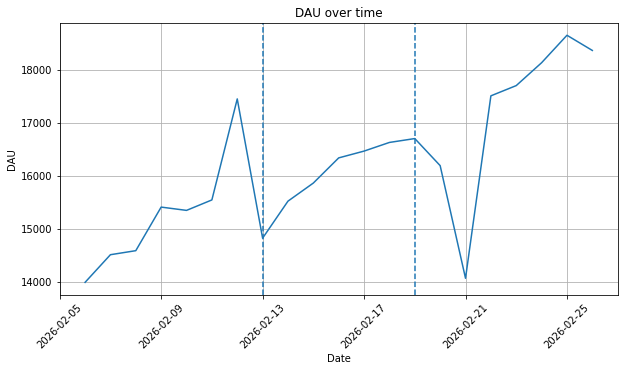

In [120]:
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['dau'])

plt.title('DAU over time')
plt.xlabel('Date')
plt.ylabel('DAU')

plt.axvline(pd.to_datetime('2026-02-13'), linestyle='--')
plt.axvline(pd.to_datetime('2026-02-19'), linestyle='--')

plt.xticks(rotation=45)
plt.grid()

plt.show()

До флэшмоба не наблюдается устойчивого роста DAU, однако это не позволяет однозначно связать рост во время флэшмоба именно с ним — требуется дополнительная проверка.

После окончания флэшмоба наблюдается резкий рост DAU, который начинается через несколько дней. Это может указывать на влияние внешних факторов или на отложенный эффект, однако без дополнительных данных (например, по источникам трафика) невозможно сделать точный вывод.

In [121]:
q = '''
SELECT toDate(time) as date, countIf(action = 'like') AS likes, countIf(action = 'view') AS views, likes/views AS ctr
FROM simulator_20260220.feed_actions
WHERE toDate(time) BETWEEN '2026-02-06' AND '2026-02-26'
GROUP BY date
ORDER BY date
'''

## CTR

In [122]:
df = ph.read_clickhouse(q, connection = connection)
df.head()

,date,likes,views,ctr
0,2026-02-06,109499,493534,0.221867
1,2026-02-07,112304,531289,0.211380
2,2026-02-08,94052,459383,0.204735
3,2026-02-09,104125,512583,0.203138
4,2026-02-10,107330,504253,0.212850


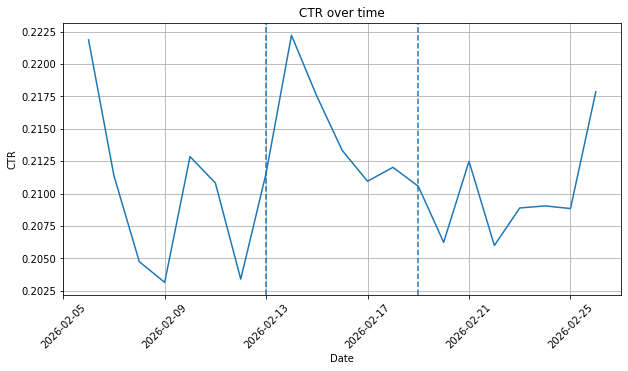

In [123]:
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['ctr'])

plt.title('CTR over time')
plt.xlabel('Date')
plt.ylabel('CTR')

plt.axvline(pd.to_datetime('2026-02-13'), linestyle='--')
plt.axvline(pd.to_datetime('2026-02-19'), linestyle='--')

plt.xticks(rotation=45)
plt.grid()

plt.show()

CTR увеличился в начале флэшмоба, достиг локального максимума, однако затем вернулся к прежнему уровню, что указывает на краткосрочный эффект без устойчивых изменений.

Рост CTR перед началом флэшмоба может свидетельствовать о предварительном анонсе, однако для подтверждения необходимо проанализировать поведение пользователей или источники трафика в этот период.

## actions per users

In [124]:
q = '''
SELECT 
    date,
    AVG(actions_per_user) as avg_actions_per_user
FROM (
    SELECT 
        toDate(time) as date,
        user_id,
        COUNT(*) as actions_per_user
    FROM simulator_20260220.feed_actions
    WHERE toDate(time) BETWEEN '2026-02-06' AND '2026-02-26'
    GROUP BY date, user_id
)
GROUP BY date
ORDER BY date
'''

In [125]:
df = ph.read_clickhouse(q, connection=connection)
df.head()

,date,avg_actions_per_user
0,2026-02-06,43.086096
1,2026-02-07,44.333747
2,2026-02-08,37.924690
3,2026-02-09,40.009602
4,2026-02-10,39.837350


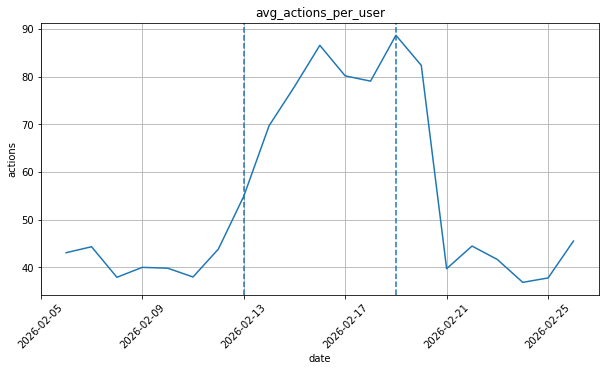

In [126]:
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['avg_actions_per_user'])

plt.title('avg_actions_per_user')
plt.xlabel('date')
plt.ylabel('actions')

plt.axvline(pd.to_datetime('2026-02-13'), linestyle='--')
plt.axvline(pd.to_datetime('2026-02-19'), linestyle='--')

plt.xticks(rotation=45)
plt.grid()

plt.show()

Как и CTR средняя активность пользователя имеет тенденцию повышения до начала флешмоба и в течении мероприятия она росла. Но в отличие от CTR имела постоянный высокий уровень в течении периода проведения флэшмоба. ПОсле мероприятия метрика упала на уровень до начала флэшмоба. Можно утверждать, проанализировав 3 метрики, что у флэшмоба выскоий краткосрочный эффект, но без дальнейшего роста вне мероприятия.

## Вывод

Во время флэшмоба наблюдается рост ключевых метрик: DAU увеличился, а среднее число действий на пользователя выросло почти в 2 раза, что указывает на значительное повышение пользовательской активности в период проведения акции.

Однако после завершения флэшмоба все метрики возвращаются к исходному уровню, что говорит об отсутствии долгосрочного эффекта. CTR также демонстрирует лишь кратковременный рост без устойчивых изменений.

Таким образом, флэшмоб является эффективным инструментом краткосрочного повышения активности, но не влияет на удержание пользователей.

Рекомендуется использовать подобные механики как временные акции для стимулирования активности, а также рассмотреть способы закрепления эффекта, например через регулярные активности или изменения продукта.

## CausalImpact DAU

In [134]:
q = '''
SELECT toDate(time) as date, count(DISTINCT user_id) as dau
FROM simulator_20260220.feed_actions
WHERE toDate(time) BETWEEN '2026-01-26' AND '2026-02-26' AND action = 'view'
GROUP BY date
ORDER BY date
'''

In [135]:
df = ph.read_clickhouse(q, connection=connection)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df = df[['dau']]
df.head()

,dau
date,
2026-01-26,12501
2026-01-27,12597
2026-01-28,13207
2026-01-29,12696
2026-01-30,12651


In [136]:
pre_period = ['2026-01-26', '2026-02-12']
post_period = ['2026-02-13', '2026-02-19']

In [137]:
impact_dau = CausalImpact(
    df,
    pre_period,
    post_period,
    alpha = 0.05
)

2026-03-20 14:12:08.902891: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 14:12:08.925468: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 14:12:09.836011: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 14:

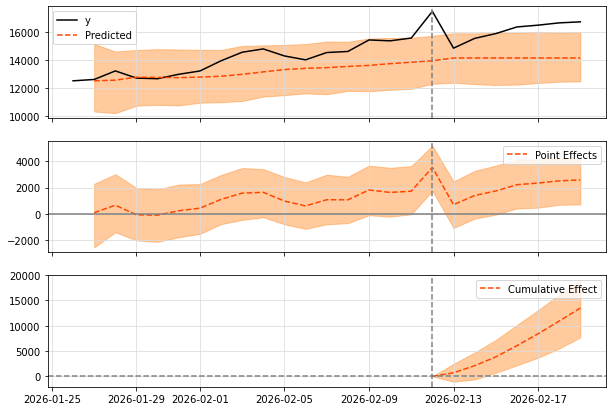

In [138]:
impact_dau.plot()

In [139]:
print(impact_dau.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    16052.71           112369.0
Prediction (s.d.)         14129.04 (390.1)   98903.31 (2730.73)
95% CI                    [13393.79, 14922.97][93756.51, 104460.78]

Absolute effect (s.d.)    1923.67 (390.1)    13465.69 (2730.73)
95% CI                    [1129.75, 2658.93] [7908.22, 18612.49]

Relative effect (s.d.)    13.61% (2.76%)     13.62% (2.76%)
95% CI                    [8.0%, 18.82%]     [8.0%, 18.82%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [140]:
print(df.head())
print(df.tail())
print(df.loc['2026-02-13':'2026-02-19'].mean())

              dau
date             
2026-01-26  12501
2026-01-27  12597
2026-01-28  13207
2026-01-29  12696
2026-01-30  12651
              dau
date             
2026-02-22  17510
2026-02-23  17703
2026-02-24  18134
2026-02-25  18651
2026-02-26  18365
dau    16052.714286
dtype: float64


- На верхнем графике видно, что после начала флэшмоба фактические значения DAU стабильно превышают прогнозируемые, что указывает на наличие эффекта. Эффект наиболее выражен в первые дни проведения акции, после чего его величина снижается, но остаётся положительной.
- Анализ pointwise effect показывает, что разница между фактическими и ожидаемыми значениями в основном положительная, а доверительный интервал в пост-периоде преимущественно не пересекает ноль, что свидетельствует о статистически значимом эффекте.
- Накопленный эффект возрастает, что подтверждает наличие суммарного положительного влияния флэшмоба.
- 

## CausalImpact CTR

In [92]:
q = '''
SELECT toDate(time) as date, countIf(action = 'like')/countIf(action = 'view') AS ctr
FROM simulator_20260220.feed_actions
WHERE toDate(time) BETWEEN '2026-01-26' AND '2026-02-26'
GROUP BY date
ORDER BY date
'''

In [93]:
df = ph.read_clickhouse(q, connection=connection)
df.head()

,date,ctr
0,2026-01-26,0.206864
1,2026-01-27,0.213408
2,2026-01-28,0.219514
3,2026-01-29,0.212136
4,2026-01-30,0.212674


In [94]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.head()

,ctr
date,
2026-01-26,0.206864
2026-01-27,0.213408
2026-01-28,0.219514
2026-01-29,0.212136
2026-01-30,0.212674


In [95]:
pre_period = ['2026-01-26', '2026-02-12']
post_period = ['2026-02-13', '2026-02-19']

In [97]:
impact_ctr = CausalImpact(
    df,
    pre_period,
    post_period,
    alpha = 0.05
)

2026-03-20 12:31:26.343619: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:31:26.360068: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:31:26.726083: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:

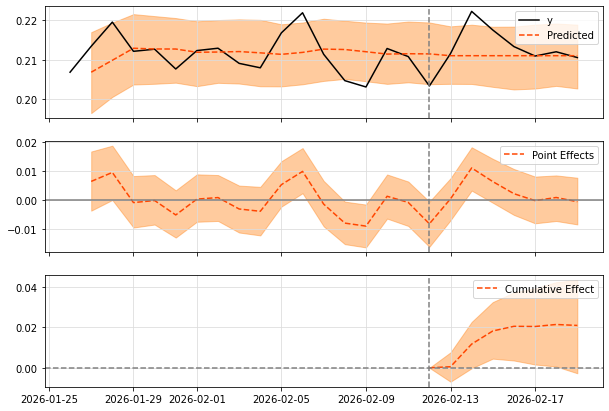

In [98]:
impact_ctr.plot()

In [99]:
print(impact_ctr.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    0.21               1.5
Prediction (s.d.)         0.21 (0.0)         1.48 (0.01)
95% CI                    [0.21, 0.21]       [1.46, 1.5]

Absolute effect (s.d.)    0.0 (0.0)          0.02 (0.01)
95% CI                    [-0.0, 0.01]       [-0.0, 0.04]

Relative effect (s.d.)    1.42% (0.77%)      1.42% (0.77%)
95% CI                    [-0.22%, 2.8%]     [-0.22%, 2.8%]

Posterior tail-area probability p: 0.04
Posterior prob. of a causal effect: 96.1%

For more details run the command: print(impact.summary('report'))


- Несмотря на небольшой положительный сдвиг CTR (~1.4%), доверительный интервал включает ноль, что говорит об отсутствии статистически значимого эффекта.
- Это означает, что флэшмоб не повлиял на вовлечённость пользователей в контент — пользователи не стали чаще ставить лайки относительно просмотров.

## Число просмотров

In [100]:
q = '''
SELECT toDate(time) AS date, countIf(action='view') AS views
FROM simulator_20260220.feed_actions
WHERE toDate(time) BETWEEN '2026-01-26' AND '2026-02-26'
GROUP BY date
ORDER BY date
'''

In [101]:
df = ph.read_clickhouse(q, connection=connection)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.head()

,views
date,
2026-01-26,354639
2026-01-27,367873
2026-01-28,471869
2026-01-29,441660
2026-01-30,420498


In [102]:
pre_period = ['2026-01-26', '2026-02-12']
post_period = ['2026-02-13', '2026-02-19']

In [103]:
impact_view = CausalImpact(
    df,
    pre_period,
    post_period,
    alpha = 0.05
)

2026-03-20 12:32:07.219147: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:32:07.236631: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:32:07.594913: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:

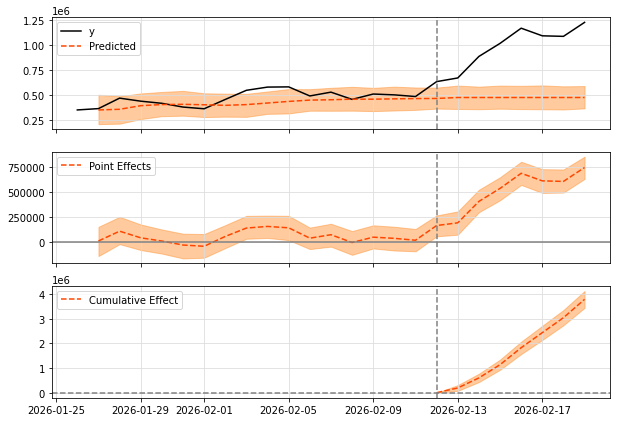

In [104]:
impact_view.plot()

In [105]:
print(impact_view.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    1019947.31         7139631.0
Prediction (s.d.)         478062.69 (25748.86)3346438.75 (180241.97)
95% CI                    [427457.0, 528390.69][2992199.09, 3698734.79]

Absolute effect (s.d.)    541884.62 (25748.86)3793192.25 (180241.97)
95% CI                    [491556.62, 592490.31][3440896.21, 4147431.91]

Relative effect (s.d.)    113.35% (5.39%)    113.35% (5.39%)
95% CI                    [102.82%, 123.94%] [102.82%, 123.94%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


- После запуска флэшмоба наблюдается значительный рост числа просмотров: фактические значения стабильно превышают прогнозируемые, а доверительный интервал не пересекает ноль, что указывает на статистически значимый эффект.
- Средняя величина абсолютного эффекта составляет около +541 885 просмотров в день, что соответствует росту более чем на 100% относительно baseline.

## Новые посты

In [106]:
q = '''
SELECT 
    toDate(first_time) as date,
    COUNT(post_id) as new_posts
FROM (
    SELECT 
        post_id,
        MIN(time) as first_time
    FROM simulator_20260220.feed_actions
    GROUP BY post_id
)
WHERE toDate(first_time) BETWEEN '2026-01-26' AND '2026-02-26'
GROUP BY date
ORDER BY date
'''

In [107]:
df = ph.read_clickhouse(q, connection=connection)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.head()

,new_posts
date,
2026-01-26,58
2026-01-27,72
2026-01-28,72
2026-01-29,59
2026-01-30,105


In [108]:
impact_posts = CausalImpact(
    df,
    pre_period,
    post_period,
    alpha = 0.05
)

2026-03-20 12:32:46.286782: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:32:46.305972: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:32:46.683162: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:

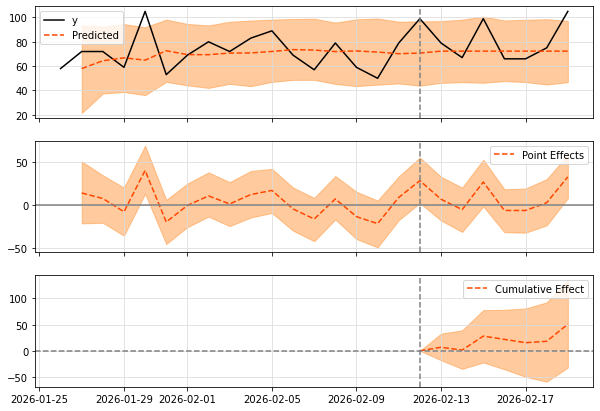

In [109]:
impact_posts.plot()

In [110]:
print(impact_posts.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    79.57              557.0
Prediction (s.d.)         72.31 (5.62)       506.17 (39.31)
95% CI                    [61.06, 83.07]     [427.4, 581.49]

Absolute effect (s.d.)    7.26 (5.62)        50.83 (39.31)
95% CI                    [-3.5, 18.51]      [-24.49, 129.6]

Relative effect (s.d.)    10.04% (7.77%)     10.04% (7.77%)
95% CI                    [-4.84%, 25.6%]    [-4.84%, 25.6%]

Posterior tail-area probability p: 0.08
Posterior prob. of a causal effect: 91.71%

For more details run the command: print(impact.summary('report'))


- Несмотря на небольшой положительный сдвиг (около +7 постов в день), доверительный интервал включает ноль, что указывает на отсутствие статистически значимого эффекта.
- Это означает, что флэшмоб не привёл к увеличению генерации контента пользователями.

## Уникальные просматриваемые посты

In [111]:
q = '''
SELECT 
    toDate(time) as date,
    COUNT(DISTINCT post_id) as unique_viewed_posts
FROM simulator_20260220.feed_actions
WHERE action = 'view'
  AND toDate(time) BETWEEN '2026-01-26' AND '2026-02-26'
GROUP BY date
ORDER BY date
'''

In [112]:
df = ph.read_clickhouse(q, connection=connection)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.head()

,unique_viewed_posts
date,
2026-01-26,177
2026-01-27,180
2026-01-28,188
2026-01-29,187
2026-01-30,209


In [113]:
impact_unique_viewed_posts = CausalImpact(
    df,
    pre_period,
    post_period,
    alpha = 0.05
)

2026-03-20 12:33:26.685530: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:33:26.701779: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:33:27.061820: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-03-20 12:

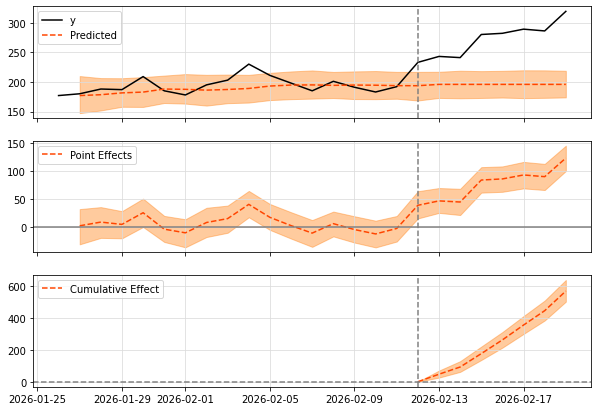

In [114]:
impact_unique_viewed_posts.plot()

In [115]:
print(impact_unique_viewed_posts.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    277.14             1940.0
Prediction (s.d.)         195.83 (4.94)      1370.81 (34.56)
95% CI                    [185.4, 204.75]    [1297.81, 1433.27]

Absolute effect (s.d.)    81.31 (4.94)       569.19 (34.56)
95% CI                    [72.39, 91.74]     [506.73, 642.19]

Relative effect (s.d.)    41.52% (2.52%)     41.52% (2.52%)
95% CI                    [36.97%, 46.85%]   [36.97%, 46.85%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


- Число уникальных просматриваемых постов статистически значимо увеличилось. Средняя величина эффекта составляет около +81 поста в день, что указывает на расширение потребляемого пользователями контента.

## Вывод

- В ходе анализа было выявлено, что флэшмоб оказал статистически значимое положительное влияние на пользовательскую активность: увеличились DAU, общее число просмотров и количество уникальных просматриваемых постов.
- В ходе анализа было выявлено, что флэшмоб оказал статистически значимое положительное влияние на пользовательскую активность: увеличились DAU, общее число просмотров и количество уникальных просматриваемых постов.
- Это указывает на то, что флэшмоб эффективно привлекает пользователей и стимулирует потребление контента, однако не влияет на глубину взаимодействия с продуктом.
- Таким образом, флэшмоб можно использовать как инструмент привлечения трафика, но для повышения вовлечённости и генерации контента необходимо внедрять дополнительные механики.